In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("smartcart_customers.csv")

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [6]:
df.shape

(2240, 22)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [8]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

## Handle Missing value

In [9]:
df["Income"]=df["Income"].fillna(df["Income"].mean())

In [10]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

## Feature engineering

In [11]:
# Age
df["Age"]=2026-df["Year_Birth"]

In [12]:
# Customer Joining Date
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)

reference_date=df["Dt_Customer"].max()

df["Customer_Tenure_Days"]=(reference_date-df["Dt_Customer"]).dt.days

In [13]:
# Spending
df["Total_Spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [14]:
# Children
df["Total_Children"]=df["Kidhome"]+df["Teenhome"]

In [15]:
# Education

df["Education"].value_counts()
df["Education"]=df["Education"].replace({
    "Basic":"undergraduate","2n Cycle":"undergraduate","Graduation":"Graduation",
    "PhD":"Postgraduate","Master":"Postgraduate"
})

In [16]:
# Marital Status
df["Marital_Status"].value_counts()
df["Living_With"]=df["Marital_Status"].replace({
    "Married":"Partner","Together":"Partner","Single":"Alone",
    "Divorced":"Alone","Widow":"Alone","Alone":"Alone","Absurd":"Alone",
    "YOLO":"Alone"
})

## Drop Columns

In [17]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [18]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children', 'Living_With'],
      dtype='object')

In [19]:
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
col_to_drop=cols+spending_cols
df_cleaned=df.drop(columns=col_to_drop)

In [20]:
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Tenure_Days', 'Total_Spending', 'Total_Children',
       'Living_With'],
      dtype='object')

In [21]:
df_cleaned.shape

(2240, 15)

# Outliers

In [22]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduation,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduation,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduation,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduation,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


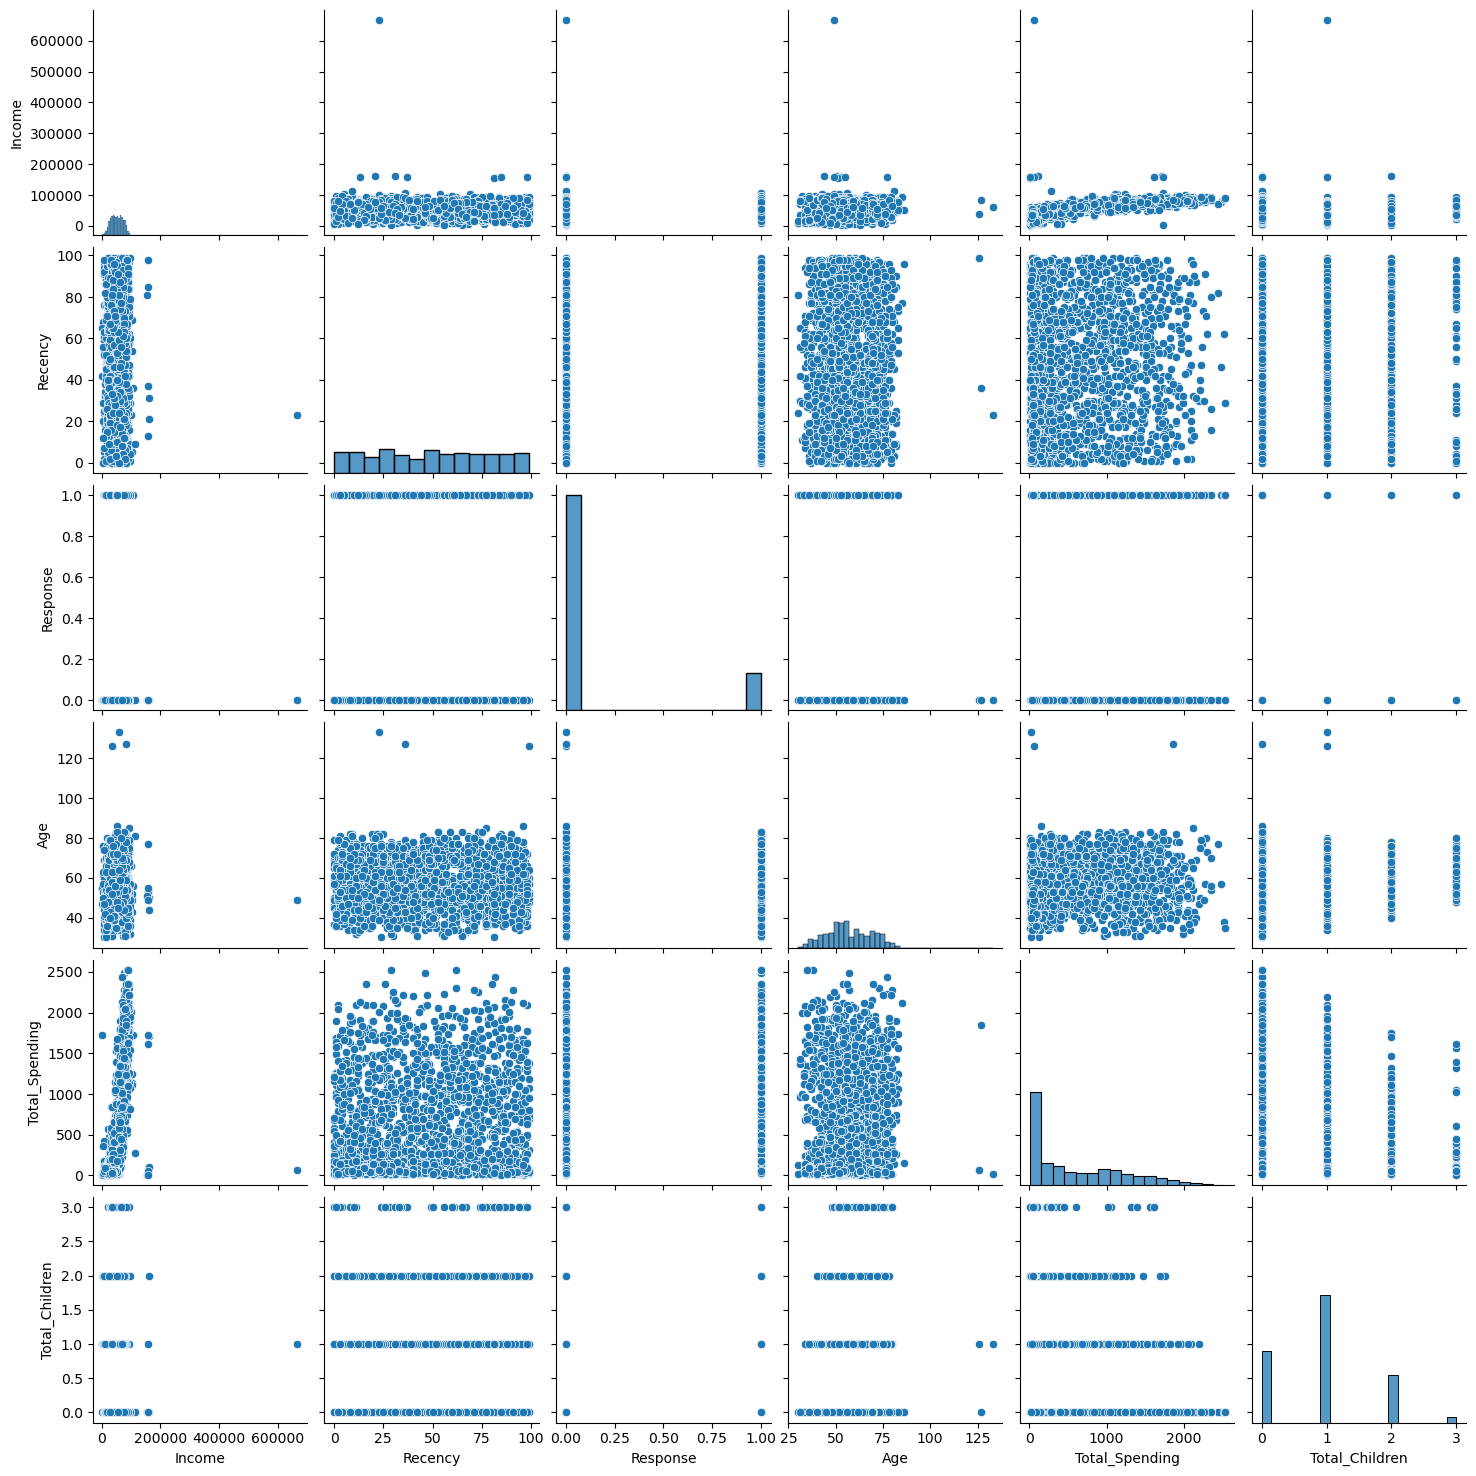

In [23]:
cols=["Income","Recency","Response","Age","Total_Spending","Total_Children"]

# relative plots of same features - pair plots
sns.pairplot(df_cleaned[cols])

In [24]:
# Remove outliers
print("Data size with outliers:",len(df_cleaned))

df_cleaned_without_outlier=df_cleaned[df_cleaned["Age"]<90]
df_cleaned_without_outlier=df_cleaned[df_cleaned["Income"]<600_000]

print("Data size without outliers:",len(df_cleaned_without_outlier))

Data size with outliers: 2240
Data size without outliers: 2239


# Heatmap (Corrilaation)

In [25]:
corr=df_cleaned_without_outlier.corr(numeric_only=True)

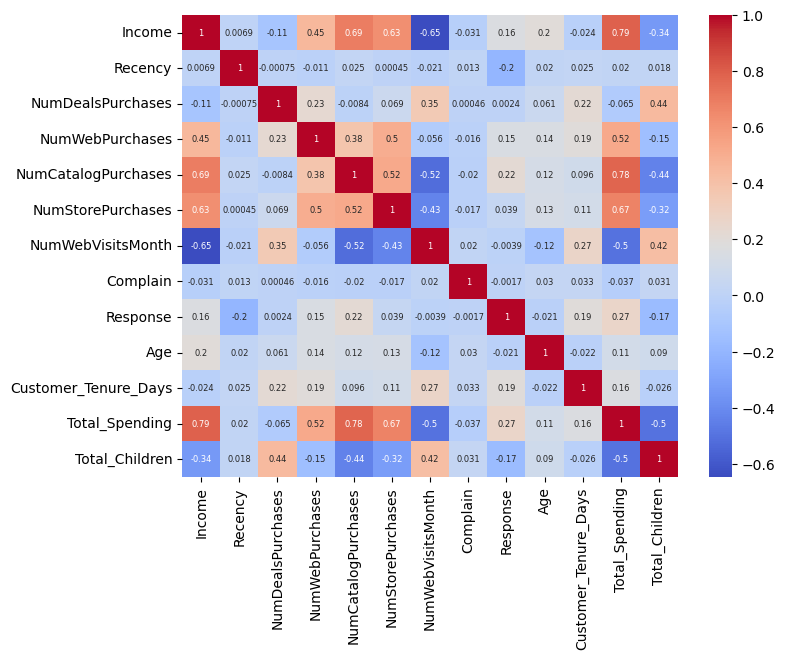

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,annot_kws={"size":6},cmap="coolwarm")
plt.show()

In [27]:
df_cleaned_without_outlier.shape

(2239, 15)

In [28]:
df_cleaned_without_outlier.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduation,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduation,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduation,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduation,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Econding

In [29]:
from sklearn.preprocessing import OneHotEncoder

In [30]:
ohe=OneHotEncoder()
cat_cols=["Education","Living_With"]
enc_cols=ohe.fit_transform(df_cleaned_without_outlier[cat_cols])

In [31]:
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned_without_outlier.index)

In [32]:
enc_df

,Education_Graduation,Education_Postgraduate,Education_undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...
2235,1.0,0.0,0.0,0.0,1.0
2236,0.0,1.0,0.0,0.0,1.0
2237,1.0,0.0,0.0,1.0,0.0
2238,0.0,1.0,0.0,0.0,1.0


In [33]:
df_encoded=pd.concat([df_cleaned_without_outlier.drop(columns=cat_cols), enc_df],axis=1)

In [34]:
df_encoded.shape

(2239, 18)

In [35]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduation,Education_Postgraduate,Education_undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling

In [36]:
from sklearn.preprocessing import StandardScaler

In [37]:
X=df_encoded

In [38]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [39]:
X_scaled

array([[ 0.28801346,  0.30662377,  0.34978184, ..., -0.36009305,
         1.34640784, -1.34640784],
       [-0.2629581 , -0.38405089, -0.1678398 , ..., -0.36009305,
         1.34640784, -1.34640784],
       [ 0.91751505, -0.79845569, -0.68546143, ..., -0.36009305,
        -0.74271701,  0.74271701],
       ...,
       [ 0.23396274,  1.44623696, -0.68546143, ..., -0.36009305,
         1.34640784, -1.34640784],
       [ 0.80689095, -1.42006289, -0.1678398 , ..., -0.36009305,
        -0.74271701,  0.74271701],
       [ 0.04186549, -0.31498343,  0.34978184, ..., -0.36009305,
        -0.74271701,  0.74271701]])

# Visualize

In [40]:
X_scaled.shape

(2239, 18)

In [41]:
# 2D
from sklearn.decomposition import PCA

In [42]:
pca=PCA(n_components=3)

X_pca=pca.fit_transform(X_scaled)

In [43]:
pca.explained_variance_ratio_

array([0.23151952, 0.11381766, 0.10376357])

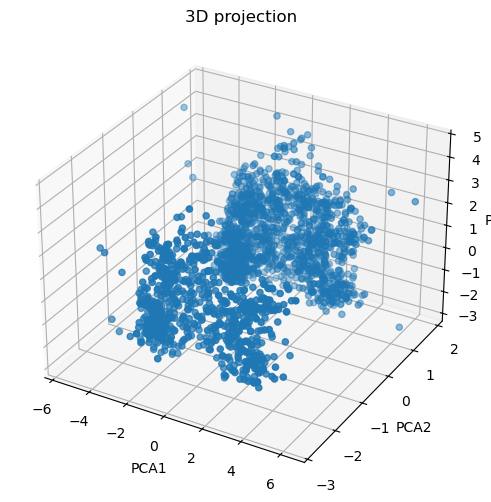

In [44]:
# plot
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection")
plt.show()

# Analyze K Value
## 1-Elbow Method

In [45]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)
    

C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to 

In [46]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k=knee.elbow

In [47]:
print("Bast K:",optimal_k)

Bast K: 4


Text(0, 0.5, 'wcss')

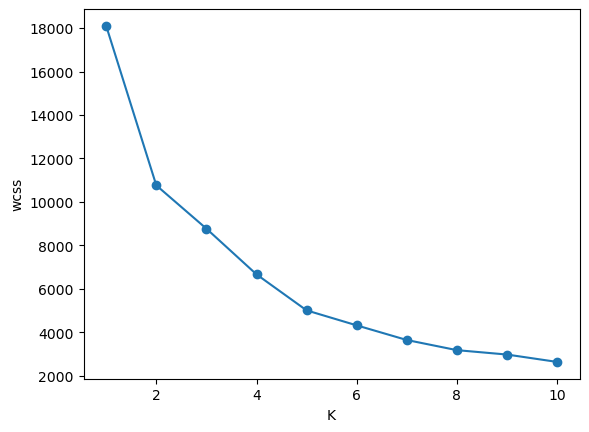

In [48]:
# plot
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("K")
plt.ylabel("wcss")

## 2.silhouette score

C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to 

Text(0, 0.5, 'silhouette_score')

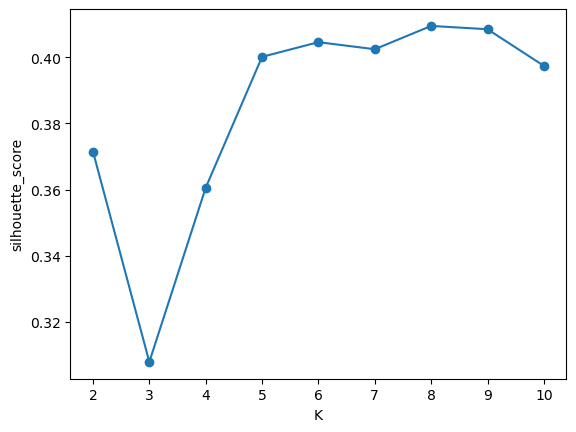

In [51]:
from sklearn.metrics import silhouette_score
scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,labels)
    scores.append(score)

# ploy
plt.plot(range(2,11),scores,marker='o')
plt.xlabel("K")
plt.ylabel("silhouette_score")

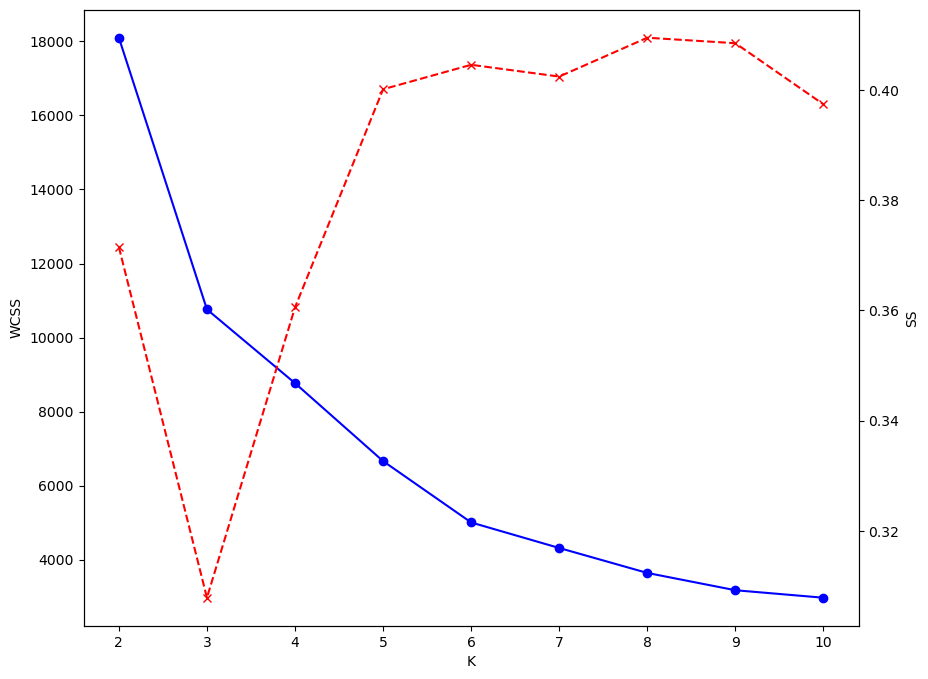

In [57]:
# combined plot

k_range=range(2,11)

fig,ax1=plt.subplots(figsize=(10,8))

ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",linestyle="--",color="red")
ax2.set_ylabel("SS")
plt.show()

# clustering

In [58]:
# k_means
kmeans=KMeans(n_clusters=4,random_state=42)
labels=kmeans.fit_predict(X_pca)

C:\Users\MAYURMAKVANA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


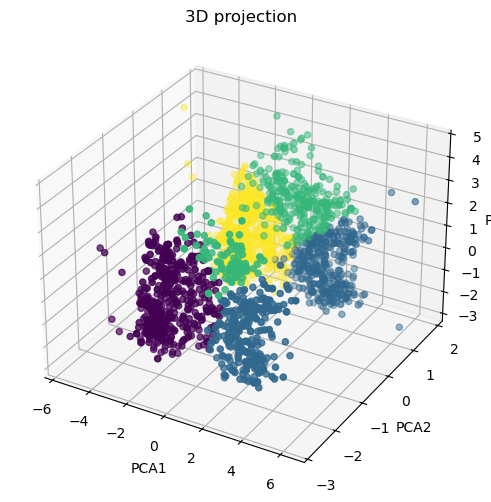

In [61]:
# plot
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection")
plt.show()

In [62]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering


In [63]:
agg_clf=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg=agg_clf.fit_predict(X_pca)


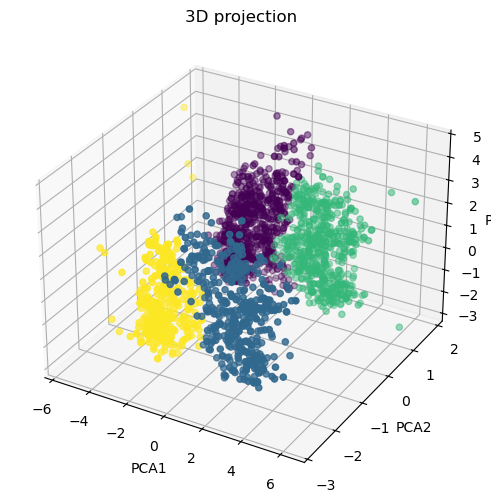

In [64]:
# plot
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection")
plt.show()

# charaterization of clusters

In [65]:
df_cleaned.shape

(2240, 15)

In [66]:
df_cleaned_without_outlier.shape

(2239, 15)

In [74]:
X["labels"]=labels_agg

In [75]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduation,Education_Postgraduate,Education_undergraduate,Living_With_Alone,Living_With_Partner,labels
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,1
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,3
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,2
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


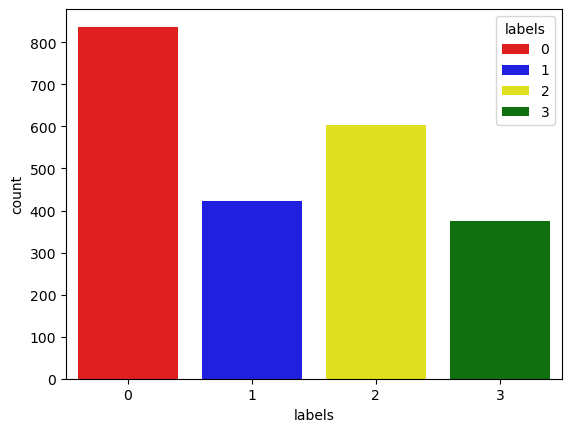

In [76]:
pal=["red","blue","yellow","green"]
sns.countplot(x=X["labels"],palette=pal,hue=X["labels"])
plt.show()

<Axes: xlabel='Total_Spending', ylabel='Income'>

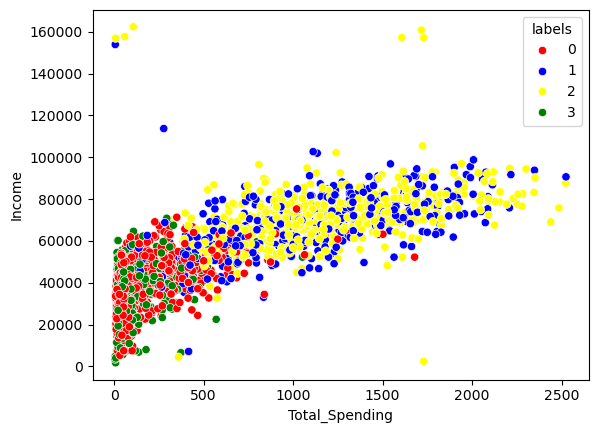

In [77]:
# income and spending patterns

sns.scatterplot(x=X["Total_Spending"],y=X["Income"],hue=X["labels"],palette=pal)

In [78]:
# cluster summary

cluster_summary=X.groupby("labels").mean()
cluster_summary

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduation,Education_Postgraduate,Education_undergraduate,Living_With_Alone,Living_With_Partner
labels,,,,,,,,,,,,,,,,,,
0,38041.934903,48.868578,2.605735,2.930705,0.839904,3.838710,6.457587,0.008363,0.082437,55.446834,345.363202,183.020311,1.265233,0.477897,0.371565,0.150538,0.000000,1.000000
1,67286.127078,49.300236,2.245863,5.666667,4.513002,7.992908,4.184397,0.004728,0.307329,59.728132,377.728132,1065.671395,0.600473,0.477541,0.456265,0.066194,1.000000,0.000000
2,71385.054735,49.212272,2.013267,5.708126,5.167496,8.565506,3.674959,0.009950,0.147595,59.482587,363.180763,1177.235489,0.562189,0.527363,0.396352,0.076285,0.000000,1.000000
3,34624.621701,49.335106,2.284574,2.273936,0.622340,3.212766,6.680851,0.015957,0.122340,54.585106,329.218085,114.590426,1.265957,0.547872,0.300532,0.151596,0.992021,0.007979
